In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv(r'C:\Users\dellh\Downloads\Employee_Attrition_Project\data\employee.csv')

In [2]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
#print("\nFirst 5 rows:\n", df.head())
print("not null",df.info())
print("\nSummary statistics for numeric columns:\n", df.describe(include='all'))

Shape: (1470, 35)

Columns:
 ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data types:
 Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int6

In [3]:
print(df.isnull().sum())  # total missing values

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [4]:
# converted col into category to reduce memory space
# 1. Identify columns to convert
# We include both the text (object) columns and the rating (integer) columns
cols_to_convert = [
     'BusinessTravel', 'Department', 'EducationField', 
    'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime',
    'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 
    'JobLevel', 'JobSatisfaction', 'PerformanceRating', 
    'RelationshipSatisfaction', 'WorkLifeBalance'
]

# 2. Convert them using a loop
for col in cols_to_convert:
    df[col] = df[col].astype('category')

# 3. Verify the changes
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Age                       1470 non-null   int64   
 1   Attrition                 1470 non-null   str     
 2   BusinessTravel            1470 non-null   category
 3   DailyRate                 1470 non-null   int64   
 4   Department                1470 non-null   category
 5   DistanceFromHome          1470 non-null   int64   
 6   Education                 1470 non-null   category
 7   EducationField            1470 non-null   category
 8   EmployeeCount             1470 non-null   int64   
 9   EmployeeNumber            1470 non-null   int64   
 10  EnvironmentSatisfaction   1470 non-null   category
 11  Gender                    1470 non-null   category
 12  HourlyRate                1470 non-null   int64   
 13  JobInvolvement            1470 non-null   category
 14  Job

In [5]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
# Convert to string first to be safe, then replace, then cast to int
df['Attrition'] = df['Attrition'].astype(str).replace({'Yes': 1, 'No': 0}).astype(int)

In [7]:
# duplicates
print(f"Duplicates: {df.duplicated().sum()}")
df = df.drop_duplicates()

Duplicates: 0


In [8]:
cols_to_convert = [
    'Attrition', 'BusinessTravel', 'Department', 'EducationField', 
    'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime',
    'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 
    'JobLevel', 'JobSatisfaction', 'PerformanceRating', 
    'RelationshipSatisfaction', 'WorkLifeBalance'
]

for col in cols_to_convert:
    print(f"Unique values in {col}: {df[col].unique().tolist()}")

Unique values in Attrition: [1, 0]
Unique values in BusinessTravel: ['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Unique values in Department: ['Sales', 'Research & Development', 'Human Resources']
Unique values in EducationField: ['Life Sciences', 'Other', 'Medical', 'Marketing', 'Technical Degree', 'Human Resources']
Unique values in Gender: ['Female', 'Male']
Unique values in JobRole: ['Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Healthcare Representative', 'Manager', 'Sales Representative', 'Research Director', 'Human Resources']
Unique values in MaritalStatus: ['Single', 'Married', 'Divorced']
Unique values in Over18: ['Y']
Unique values in OverTime: ['Yes', 'No']
Unique values in Education: [2, 1, 4, 3, 5]
Unique values in EnvironmentSatisfaction: [2, 3, 4, 1]
Unique values in JobInvolvement: [3, 2, 4, 1]
Unique values in JobLevel: [2, 1, 3, 4, 5]
Unique values in JobSatisfaction: [4, 2, 3, 1]
Unique values in PerformanceRati

In [9]:
df['JobRole'] = df['JobRole'].replace('Sales Representative', 'Sales Executive')
df.columns



Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [10]:
for col in df.columns:
    print( col , "is unquie values",df[col].unique())

Age is unquie values [41 49 37 33 27 32 59 30 38 36 35 29 31 34 28 22 53 24 21 42 44 46 39 43
 50 26 48 55 45 56 23 51 40 54 58 20 25 19 57 52 47 18 60]
Attrition is unquie values [1 0]
BusinessTravel is unquie values ['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Categories (3, str): ['Non-Travel', 'Travel_Frequently', 'Travel_Rarely']
DailyRate is unquie values [1102  279 1373 1392  591 1005 1324 1358  216 1299  809  153  670 1346
  103 1389  334 1123 1219  371  673 1218  419  391  699 1282 1125  691
  477  705  924 1459  125  895  813 1273  869  890  852 1141  464 1240
 1357  994  721 1360 1065  408 1211 1229  626 1434 1488 1097 1443  515
  853 1142  655 1115  427  653  989 1435 1223  836 1195 1339  664  318
 1225 1328 1082  548  132  746  776  193  397  945 1214  111  573 1153
 1400  541  432  288  669  530  632 1334  638 1093 1217 1353  120  682
  489  807  827  871  665 1040 1420  240 1280  534 1456  658  142 1127
 1031 1189 1354 1467  922  394 1312  750  441  684  249  841

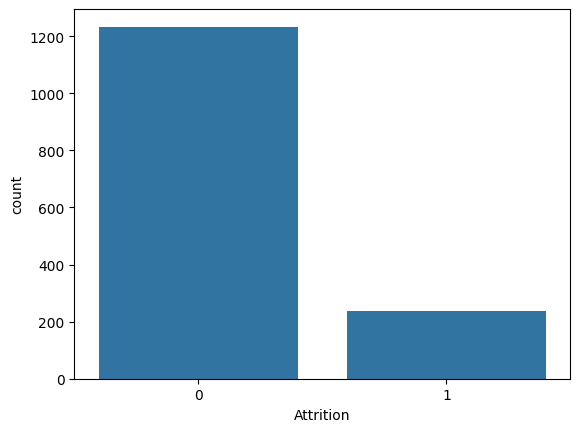

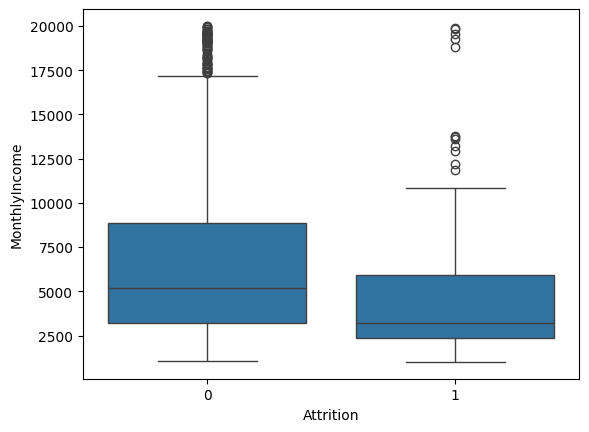

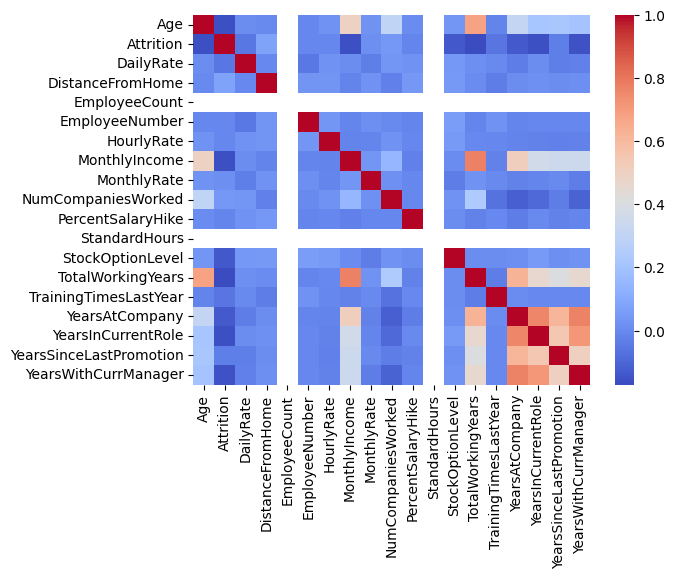

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Attrition', data=df)
plt.show()

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.show()

sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

In [12]:
df.columns


Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [13]:
#outliers

# Load your data (example)
# df = pd.read_csv('your_employee_data.csv')

# 1. Select only numerical columns (excluding the target 'Attrition' if it's numerical)
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove identifier columns if present (adjust names to your data)
exclude_cols = ['EmployeeID', 'EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
numerical_cols = [col for col in numerical_cols if col not in exclude_cols and col != 'Attrition']

# 2. Function to find outliers using IQR
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers, lower, upper

# 3. See outliers for each column (just printing)
for col in numerical_cols:
    outliers, low, high = find_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers (range: {low:.2f} – {high:.2f})")
    if len(outliers) > 0:
        print(outliers[[col]].head(), "\n")

# 4. Drop rows that have an outlier in ANY numerical column
# Simple loop: keep row only if it's within bounds for all columns
df_clean = df.copy()
for col in numerical_cols:
    _, low, high = find_outliers_iqr(df_clean, col)
    df_clean = df_clean[(df_clean[col] >= low) & (df_clean[col] <= high)]

print(f"Original rows: {len(df)}")
print(f"Rows after removing outliers: {len(df_clean)}")

Age: 0 outliers (range: 10.50 – 62.50)
DailyRate: 0 outliers (range: -573.00 – 2195.00)
DistanceFromHome: 0 outliers (range: -16.00 – 32.00)
HourlyRate: 0 outliers (range: -5.62 – 137.38)
MonthlyIncome: 114 outliers (range: -5291.00 – 16581.00)
     MonthlyIncome
25           19094
29           18947
45           19545
62           18740
105          18844 

MonthlyRate: 0 outliers (range: -10574.75 – 39083.25)
NumCompaniesWorked: 52 outliers (range: -3.50 – 8.50)
     NumCompaniesWorked
4                     9
38                    9
50                    9
95                    9
105                   9 

PercentSalaryHike: 0 outliers (range: 3.00 – 27.00)
StockOptionLevel: 85 outliers (range: -1.50 – 2.50)
    StockOptionLevel
6                  3
64                 3
65                 3
83                 3
88                 3 

TotalWorkingYears: 63 outliers (range: -7.50 – 28.50)
     TotalWorkingYears
18                  31
62                  29
85                  37
98     

In [14]:
df.shape

(1470, 35)